# Notebook 1 - Newton's Method

## Introduction

Newton's Method is one of the most elegant algorithms in numerical optimization — quadratically convergent, fully informed by second-order curvature, and exact in its step computation. Yet these same properties make it brittle. When the local quadratic model of the objective is inaccurate, or the Hessian becomes indefinite, the method can overshoot, oscillate, or diverge entirely.

This notebook investigates the behavior of Newton's Method applied to the **Beale function**, an ill-conditioned benchmark whose Hessian condition number grows large away from the minimizer $(3, 0.5)$. We derive the gradient and Hessian analytically, implement the Newton step, and track convergence across iterations — exposing exactly where and why the method struggles without built-in safeguards.

## Background

### Newton's Method

Newton's Method is a second-order optimization algorithm that computes a step by solving the Newton system:

$$p_k = -H_k^{-1} \nabla f(x_k)$$

where $H_k = \nabla^2 f(x_k)$ is the Hessian at the current iterate $x_k$. The method builds a local quadratic model:

$$m_k(p) = f(x_k) + \nabla f(x_k)^\top p + \frac{1}{2} p^\top H_k \, p$$

and takes the step that minimizes this model exactly, without restriction. Applied to the Beale function, 
the Hessian takes the form:

$$H(x, y) = \begin{bmatrix} \frac{\partial^2 f}{\partial x^2} & \frac{\partial^2 f}{\partial x \partial y} \\ \frac{\partial^2 f}{\partial y \partial x} & \frac{\partial^2 f}{\partial y^2} \end{bmatrix}$$

where each entry is a sum of terms involving the three residuals $(1.5 - x + xy)$, $(2.25 - x + xy^2)$, 
and $(2.625 - x + xy^3)$. Away from the minimizer $(3, 0.5)$, this Hessian becomes highly ill-conditioned, 
with condition number $\kappa(H) \gg 1$, causing the Newton step $p_k$ to become poorly scaled.

**Strengths:**
- Quadratic convergence near a solution when $H_k$ is positive definite and Lipschitz continuous
- Exact second-order information makes each step highly informed

**Weaknesses:**
- Requires the Hessian to be positive definite; indefinite or singular Hessians cause the method to fail or diverge
- The full Newton step may overshoot when far from the solution, where the quadratic model is inaccurate
- Computing and factoring the Hessian is $O(n^3)$ per iteration, expensive for large-scale problems
- No built-in globalization: the method can diverge without a line search or other safeguard
- Particularly fragile on ill-conditioned functions like Beale's, where $\kappa(H)$ amplifies numerical 
  errors in the solve $H_k p_k = -\nabla f(x_k)$

## Implementation

To implement this algorithm we will define a few arguments that will be used to implement **Newton's Method**.

---

### Objective Function

The Beale function is defined as:

$$f(x, y) = (1.5 - x + xy)^2 + (2.25 - x + xy^2)^2 + (2.625 - x + xy^3)^2$$

We define the three residuals for convenience:

$$r_1 = 1.5 - x + xy, \quad r_2 = 2.25 - x + xy^2, \quad r_3 = 2.625 - x + xy^3$$

so that $f(x, y) = r_1^2 + r_2^2 + r_3^2$.

---

### Gradient

The gradient $\nabla f(x, y) = [\partial f / \partial x, \; \partial f / \partial y]^\top$ is derived 
by differentiating each residual:

$$\frac{\partial r_1}{\partial x} = -1 + y, \qquad \frac{\partial r_1}{\partial y} = x$$

$$\frac{\partial r_2}{\partial x} = -1 + y^2, \qquad \frac{\partial r_2}{\partial y} = 2xy$$

$$\frac{\partial r_3}{\partial x} = -1 + y^3, \qquad \frac{\partial r_3}{\partial y} = 3xy^2$$

Applying the chain rule $\partial f / \partial x = 2r_1 \partial r_1/\partial x + 2r_2 \partial r_2/\partial x 
+ 2r_3 \partial r_3/\partial x$:

$$\frac{\partial f}{\partial x} = 2r_1(-1 + y) + 2r_2(-1 + y^2) + 2r_3(-1 + y^3)$$

$$\frac{\partial f}{\partial y} = 2r_1(x) + 2r_2(2xy) + 2r_3(3xy^2)$$

Therefore:

$$\nabla f(x, y) = \begin{bmatrix} 2r_1(y - 1) + 2r_2(y^2 - 1) + 2r_3(y^3 - 1) \\ 2r_1 x + 4r_2 xy + 6r_3 xy^2 \end{bmatrix}$$

---

### Hessian

The Hessian $H(x, y) \in \mathbb{R}^{2 \times 2}$ is the matrix of second-order partial derivatives:

$$H(x, y) = \begin{bmatrix} \partial^2 f / \partial x^2 & \partial^2 f / \partial x \partial y \\ \partial^2 f / \partial y \partial x & \partial^2 f / \partial y^2 \end{bmatrix}$$

The full Hessian is:

$$H(x,y) = \begin{bmatrix} 2\displaystyle\sum_{i=1}^{3}(y^i - 1)^2 & 2\displaystyle\sum_{i=1}^{3}\left[r_i \cdot iy^{i-1} + x(y^i-1)iy^{i-1}\right] \\[10pt] 2\displaystyle\sum_{i=1}^{3}\left[r_i \cdot iy^{i-1} + x(y^i-1)iy^{i-1}\right] & 2\displaystyle\sum_{i=1}^{3}\left[r_i \cdot i(i-1)xy^{i-2} + i^2x^2y^{2(i-1)}\right] \end{bmatrix}$$

Note that $H$ is symmetric by Schwarz's theorem ($\partial^2 f / \partial x \partial y = \partial^2 f / \partial y \partial x$), 
as expected.

---

### Newton Step

Given the gradient and Hessian at iterate $(x_k, y_k)$, the Newton step solves:

$$H_k \, p_k = -\nabla f(x_k, y_k)$$

$$\begin{bmatrix} H_{xx} & H_{xy} \\ H_{yx} & H_{yy} \end{bmatrix} \begin{bmatrix} \Delta x \\ \Delta y \end{bmatrix} = -\begin{bmatrix} \partial f / \partial x \\ \partial f / \partial y \end{bmatrix}$$

For the $2 \times 2$ case this can be solved analytically via Cramer's rule:

$$\Delta x = \frac{-H_{yy} \cdot g_x + H_{xy} \cdot g_y}{\det(H_k)}, \qquad \Delta y = \frac{H_{yx} \cdot g_x - H_{xx} \cdot g_y}{\det(H_k)}$$

where $\det(H_k) = H_{xx} H_{yy} - H_{xy}^2$. In practice we use `np.linalg.solve` to avoid 
explicit inversion:

$$p_k = \texttt{np.linalg.solve}(H_k, -g_k)$$

The iterate is then updated as:

$$(x_{k+1}, y_{k+1}) = (x_k, y_k) + p_k$$

## Code

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from utilities import beale

In [11]:
def beale_f(x, y):
    """
    Evaluate the Beale function at a point (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        float: Function value f(x, y).
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3
    return r1**2 + r2**2 + r3**2


def beale_grad(x, y):
    """
    Compute the gradient of the Beale function at (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        np.ndarray: Gradient vector [df/dx, df/dy].
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3

    df_dx = 2*r1*(y - 1) + 2*r2*(y**2 - 1) + 2*r3*(y**3 - 1)
    df_dy = 2*r1*x       + 4*r2*x*y         + 6*r3*x*y**2
    return np.array([df_dx, df_dy])


def beale_hess(x, y):
    """
    Compute the Hessian of the Beale function at (x, y).

    Args:
        x (float): x-coordinate.
        y (float): y-coordinate.

    Returns:
        np.ndarray: 2x2 Hessian matrix.
    """
    r1 = 1.5   - x + x * y
    r2 = 2.25  - x + x * y**2
    r3 = 2.625 - x + x * y**3

    H_xx = 2*(y - 1)**2 + 2*(y**2 - 1)**2 + 2*(y**3 - 1)**2

    H_yy = (2*x**2 + 4*r2*x + 8*x**2*y**2 + 12*r3*x*y + 18*x**2*y**4)

    H_xy = (2*r1 + 4*r2*y + 6*r3*y**2
            + 2*x*(y - 1) + 4*x*y*(y**2 - 1) + 6*x*y**2*(y**3 - 1))

    return np.array([[H_xx, H_xy],
                     [H_xy, H_yy]])

In [12]:
def newton_method(x0, y0, tol=1e-6, max_iter=100):
    """
    Newton's Method for minimizing the Beale function in 2 variables.

    At each iteration:
        1. Compute gradient g_k and Hessian H_k at (x_k, y_k)
        2. Check convergence: ||g_k|| < tol
        3. Verify H_k is positive definite via det and trace
        4. Solve H_k p_k = -g_k for the Newton step
        5. Update (x_{k+1}, y_{k+1}) = (x_k, y_k) + p_k

    Args:
        x0       (float): Initial x-coordinate.
        y0       (float): Initial y-coordinate.
        tol      (float): Gradient norm convergence tolerance.
        max_iter (int):   Maximum number of iterations.

    Returns:
        dict: {
            'path'       : list of (x, y) iterates,
            'f_vals'     : list of function values,
            'grad_norms' : list of gradient norms,
            'cond_nums'  : list of Hessian condition numbers,
            'converged'  : bool
        }
    """
    xk, yk       = x0, y0
    path         = [(xk, yk)]
    f_vals       = [beale_f(xk, yk)]
    grad_norms   = []
    cond_nums    = []
    converged    = False

    for k in range(max_iter):
        gk = beale_grad(xk, yk)
        Hk = beale_hess(xk, yk)

        grad_norm = np.linalg.norm(gk)
        cond      = np.linalg.cond(Hk)
        grad_norms.append(grad_norm)
        cond_nums.append(cond)

        # Convergence check
        if grad_norm < tol:
            converged = True
            print(f"Converged at iteration {k}  |  f = {beale_f(xk, yk):.2e}  |  ||g|| = {grad_norm:.2e}")
            break

        # Positive definiteness check
        det   = np.linalg.det(Hk)
        trace = np.trace(Hk)
        if det <= 0 or trace <= 0:
            print(f"Iteration {k}: Hessian is indefinite or singular (det={det:.2e}, trace={trace:.2e}). Stopping.")
            break

        # Newton step: H_k p_k = -g_k
        pk = np.linalg.solve(Hk, -gk)

        xk += pk[0]
        yk += pk[1]

        path.append((xk, yk))
        f_vals.append(beale_f(xk, yk))

    if not converged:
        print(f"Did not converge within {max_iter} iterations.")

    return {
        'path'       : path,
        'f_vals'     : f_vals,
        'grad_norms' : grad_norms,
        'cond_nums'  : cond_nums,
        'converged'  : converged
    }

In [16]:
# Run Newton's Method from two starting points
result_near = newton_method(x0=2.0,  y0=0.4,  tol=1e-6, max_iter=100)  # near minimizer
result_far  = newton_method(x0=-1.0, y0=3.0,  tol=1e-6, max_iter=100)  # far from minimizer

Converged at iteration 7  |  f = 7.52e-22  |  ||g|| = 3.88e-11
Iteration 0: Hessian is indefinite or singular (det=-4.48e+06, trace=3.88e+03). Stopping.
Did not converge within 100 iterations.


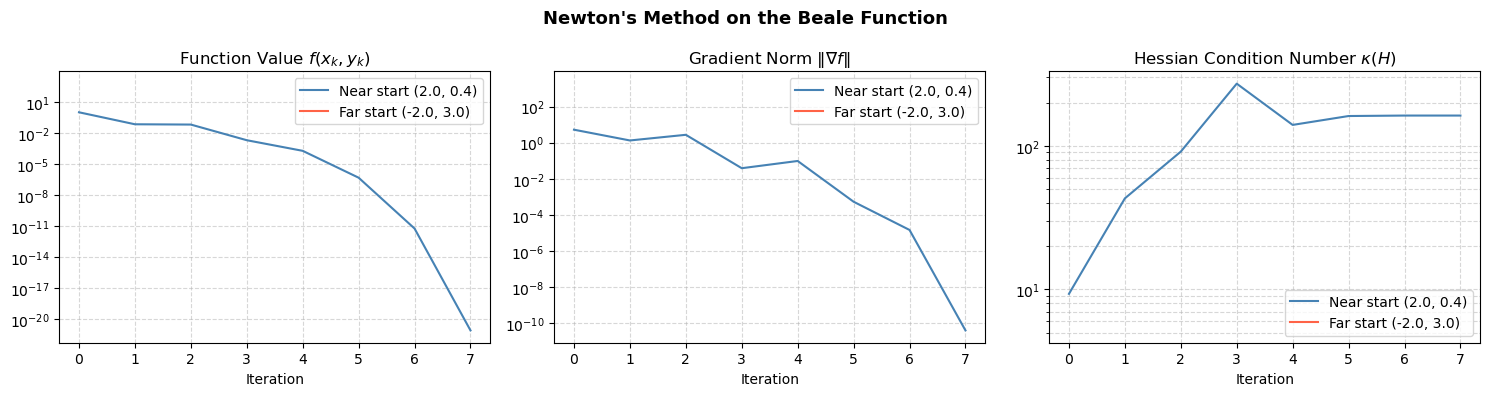

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for result, label, color in [
    (result_near, 'Near start (2.0, 0.4)',   'steelblue'),
    (result_far,  'Far start (-2.0, 3.0)',   'tomato')
]:
    iters = range(len(result['f_vals']))
    axes[0].semilogy(iters, result['f_vals'],     label=label, color=color)
    axes[1].semilogy(range(len(result['grad_norms'])), result['grad_norms'], label=label, color=color)
    axes[2].semilogy(range(len(result['cond_nums'])),  result['cond_nums'],  label=label, color=color)

axes[0].set_title('Function Value $f(x_k, y_k)$');   axes[0].set_xlabel('Iteration')
axes[1].set_title('Gradient Norm $\\|\\nabla f\\|$');  axes[1].set_xlabel('Iteration')
axes[2].set_title('Hessian Condition Number $\\kappa(H)$'); axes[2].set_xlabel('Iteration')

for ax in axes:
    ax.legend()
    ax.grid(True, which='both', linestyle='--', alpha=0.5)

plt.suptitle("Newton's Method on the Beale Function", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

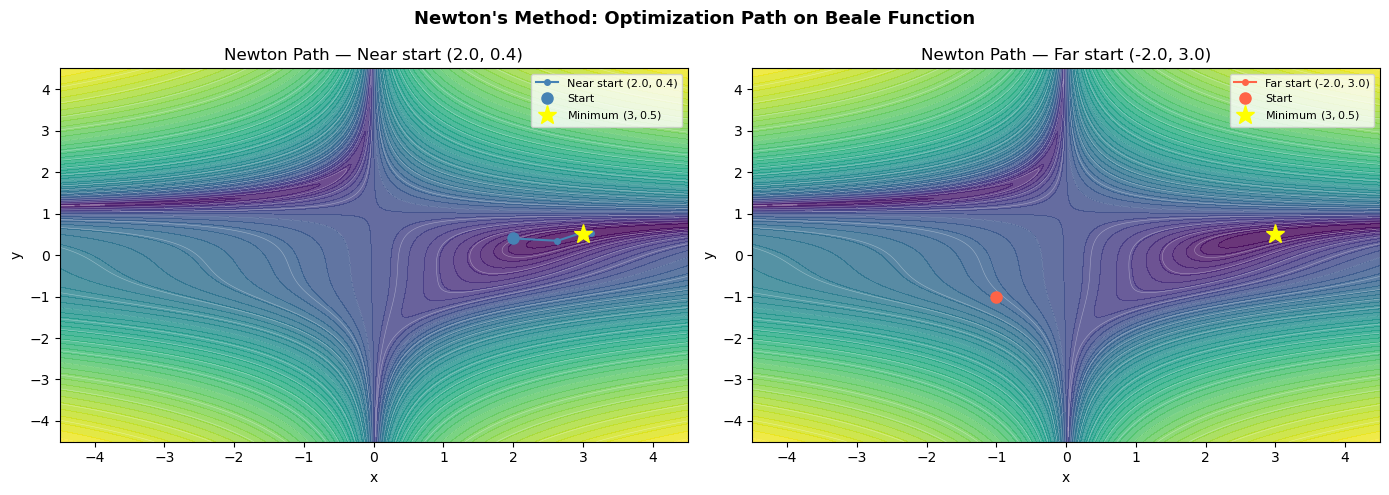

In [15]:
# Contour plot with optimization path
x_grid = np.linspace(-4.5, 4.5, 400)
y_grid = np.linspace(-4.5, 4.5, 400)
X, Y   = np.meshgrid(x_grid, y_grid)
Z      = beale_f(X, Y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, result, label, color in [
    (axes[0], result_near, 'Near start (2.0, 0.4)',  'steelblue'),
    (axes[1], result_far,  'Far start (-2.0, 3.0)', 'tomato')
]:
    ax.contourf(X, Y, np.log1p(Z), levels=50, cmap='viridis', alpha=0.8)
    ax.contour(X, Y,  np.log1p(Z), levels=20, colors='white', linewidths=0.4, alpha=0.4)

    xs, ys = zip(*result['path'])
    ax.plot(xs, ys, 'o-', color=color, markersize=4, linewidth=1.5, label=label)
    ax.plot(xs[0], ys[0], 'o', color=color,   markersize=8, label='Start')
    ax.plot(3, 0.5, '*', color='yellow', markersize=14, label='Minimum $(3, 0.5)$')

    ax.set_title(f"Newton Path — {label}")
    ax.set_xlabel('x');  ax.set_ylabel('y')
    ax.legend(fontsize=8)

plt.suptitle("Newton's Method: Optimization Path on Beale Function", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()